# Kapitel 6 - Klustring

## Faktafrågor

### 1. 
**Klustring** (clustering) är en typ av **oövervakad maskininlärning** (unsupervised learning). Det innebär att algoritmen helt på egen hand analyserar ett dataset utan färdiga facit eller etiketter, letar efter naturliga mönster och likheter, och delar in dataobjekten i grupper (**kluster**).

Huvudregeln är att datapunkterna som hamnar i samma kluster ska vara så lika varandra som möjligt, samtidigt som datapunkterna i olika kluster ska skilja sig åt så mycket som möjligt. 

Ett vanligt exempel är **K-Means**, där man på förhand bestämmer hur många kluster (grupper) algoritmen ska försöka hitta.

#### Exempel på tillämpningsområden
1. **Kundsegmentering (Marketing):**
Företag använder klustringför att dela upp sin kundbas i olika grupper baserat på köpbeteende, ålder, intressen eller inkomst. Det gör att man kan skräddarsy marknadsföring och kampanjer för just en specifik kundgrupp istället för att skicka samma sak till alla. 

2. **Bildsegmentering och datorseende:**
Inom bildbehandling kan lustring användas för att gruppera pixlar med liknande färg eller ljusstyrka, vilket är ett första steg för att urskilja objekt eller ta bort bakgrunder i bilder. 

3. **Anomalidetektion (Bedrägeriupptäckt):**
Genom att klustra normalt beteende (t.ex. hur en viss användare brukar handla med sitt bankkort) kan transaktioner eller beteenden som inte passar in i nåot kluster flaggas som misstänkta eller potentiella bedgrägerier (outliers). 

4. **Dokument- och textgruppering:**
Om man har tusentals nyhetsartiklar eller dokumment kan klustring automatiskt sortera dem efter ämne (t.ex. sport, politik, teknik eller ekonomi) utan att någon människa behöver läsa eller tagga dem i förväg.

5. **Genetik och bioinformatik:**
Inom biologin används klustring för att gruppera gener med liknande uttrycksmönster, vilket hjälper forskare att förstå vilka gener som samverkar vid olika sjukdomar.

### Uppgift 2. 
Bilderna visar hur K-means fungerar när data passar modellen och vad som kan gå fel när data inte passar K-means.

K-means är en klustringsalgoritm, vilket betyder att den försöker dela upp datapunkter i ett bestämt antal grupper, så kallade kluster. 
Algoritmen fungerar ungefär så här: 
1. **Bestäm antal kluster, K**
Man anger hr många kluster man vill hitta, exempelvis `K = 3`.
2. **Placera ut K centroider**
Algoritmen börjar med K stycken centrumpunkter, så kallade **centroider.**
3. **Tilldela varje datapunkt till närmaste centroid**
Varje punkt hamnar i det kluster vars centroid den ligger närmast.
4. **Flytta centroiderna**
För varje kluster beräknas medelvärdet av datapunkterna. Centroiden flyttas då till detta medelvärde. 
5. **Upprepa steg 3-4**
Punkterna tilldelas på nytt och centroiderna flyttas igen. Detta fortsätter till klustren stabiliseras. 

#### **Koppling till den första bilden - "Sanna kluster"**
Den första bilden visar hur de **egentliga klustren** ser ut i olika situationer.
Överst till vänster finns exempelvis **tre tydliga kluster**. Här fungerar K-means bra eftersom grupperna är relativt tydliga och ungefär cirkulära.

Men bilden visar också situationer där klustern: 
- är **sfäriska/ovala på olika sätt**
- har **olika spridning**
- har **olika storlek**
Det är viktigt eftersom K-means framför aööt fungerar bra när klustren är ungefär runda och har liknande storlek och spridning.

#### **Koppling till den andra bilden - "Dålig resultat med K-means"**
Den andra bilden visar vad som händer när K-means används på data som inte passar dessa antaganden.
- **Övre vänster:** Fel antal kluster har valts. Om det egentligen finns tre kluster men man väljer fel `K`, blir grupperingen dålig.
- **Övre höger:** Klustren är inte sfärsika utan har exempelvis en långsmal form. K-means har svårt att följa sådana former.
- **Nedre vänster:** Klustren har olika varians/spridning. K-means kan då dela upp ett stort och utspritt kluster på ett olämpligt sätt. 
- **Nedre höger:** Klustren har olika storlek. Ett stort kluster och ett litet kluster kan därför gruppers på ett dåligt sätt. 

## Resonemangsfrågor

### Uppgift 3. 
När man bygger en **K-Means**-modell vet man nästan aldrig på förhand hur många grupper ($K$) som finns i datan. Eftersom K-Means kräver att man anger antalet kluster i förväg måste man använda utvärderingsmått för att hitta det optimala värdet.De tre vanligaste och mest kraftfulla metoderna för att göra detta är **Inertia, Silhouette Score och Silhouette Diagram.**

#### 1. Inertia (The Elbow Method / Armbågsmetoden)
- **Vad det är:** Inertia mäter den totala summan av de kvadratiska avstånden från varje datapunkts till dess tilldelade klustermedelpunkt (centroid). Det beskriver alltså hur "kompakta" klustren är.

- **Hur man använder det:** Man tränar K-Means för ett spann av olika $K$-värden (t.ex. $K = 1$ till 10) och ritar upp Inertia i ett linjediagram. När $K$ ökar kommer inertia alltid att minska (eftersom fler kluster gör klustren mindre).

- **Armbågsregeln:** I diagrammet bildas ofta en kurva som planar ut likt en arm. Den punkt där kurvan knäckts ("armbågen") markerar en bra balans: att lägga till fler kluster ger inte längre någon märkbar förbättring av kompaktheten.

#### 2. Silhouette Score (Silhuettpoäng)
- **Vad det är:** Silhouette Score mäter hur väl separerade klustren är. Den tittar på två saker för varje datapunkt:
  1. Cohesion (sammanhållning): Hur nära punkten är andra punkter i samma kluster.
  2. Separation: Hur långt ifrån punkter i det närmast liggande grannklustret den är.

- **Skalan:** Värdet ligger alltid mellan -1 och +1.
  - Ett värde nära +1 betyder att punkten ligger långt inne i sitt eget kluster och långt från andra kluster (bra!).
  - Ett värde nära 0 betyder att punkten ligger nära gränsen mellan två kluster.
  - Ett värde på negativa tal betyder att punkten troligtvis hamnat i fel kluster.

- **Hur man använder det:** Man beräknar den genomsnittliga silhuettpoängen för alla dataobjekt för olika $K$-värden. Det $K$-värde som ger **högst genomsnittlig poäng** är det optimala.

#### 3. Silhouette Diagram (Silhuett-diagram)
- **Vad det är:** En visuell vidareutveckling av Silhouette Score. Istället för att bara få ett medeltal ritar man upp ett diagram för varje enskilt kluster uppdelat per $K$-värde.

- **Hur det ser ut:** Det liknar liggande knivblad eller staplar för varje kluster (där varje horisontell linje representerar en datapunkt, sorterad efter sitt silhuettvärde).

- **Vad man letar efter:**
  1. **Tjocklek:** Klustren bör vara ungefär lika breda (lika många medlemmar). Om ett kluster är jättetunt medan ett annat är enormt kan $K$ vara felvalt.

  2. **Tröskelvärde:** Alla kluster bör sträcka sig över den röda streckade linjen som visar genomsnittspoängen för hela datasetet. Om många punkter sticker ut till vänster om medellinjen (har låga eller negativa poäng) är klustringen dålig för det antalet kluster.

#### Sammanfattning av arbetsflödet i praktiken:
Ofta kombinerar man dessa metoder: man börjar med **Inertia** (Armbågsmetoden) för att få en grov uppfattning om ett rimligt intervall av $K$-värden (t.ex. mellan 2 och 6). Därefter finjusterar och validerar man det exakta valet genom att titta på **Silhouette Score** och detaljstudera **Silhouette Diagram** för att säkerställa att klustren faktiskt är väldefinierade och separerade.

### Uppgift 4. 
Om man tittar på **Figur 6.10** (Inertia-diagrammet längst ner) och de tillhörande klusterfördelningarna ovanför (Figur 6.9) skulle jag ha valt $K = 4$ kluster.

#### Varför $K = 4$?
1. **Armbågen (The Elbow):** I Inertia-grafen ser man tydligt pilen som pekar på en "armbåge" vid $K = 4$. Efter denna punkt planar kurvan ut drastiskt. Det betyder att vi får en stor förbättring i att minska avstånden (öka kompaktheten) upp till 4 kluster, men att lägga till fler (t.ex. 5, 6 eller 8) ger väldigt liten märkbar förbättring i förhållande till komplexiteten.

2. **Datans struktur:** Om man kollar på fördelningen av punkterna i diagrammen ovanför ser man att data består av ett antal distinkta moln (kluster). Om man tvingar in det i $k = 3$ (vänstra bilden) slås separata grupper ihop på felaktigt sätt, och om man väljer $k = 8$ (högra bilden) delas samma naturliga kluster upp godtyckligt i flera mindre bitar.

#### Är det en "exakt vetenskap"?
**Nej, det är absolut inte en exakt vetenskap.**
Att välja antalet kluster med armbågsmetoden bygger ofta på en visuell bedömning där man letar efter en "böj" på kurvan, vilket kan vara subjektivt om kurvan är flack eller saknar en knivskarp armbåge. Eftersom klustring är en oövervakad metod finns det inget objektivt "rätt eller fel" facit – det beror helt på vilken detaljnivå man är ute efter i sin analys. Därför brukar man ofta kombinera Inertia med andra mått, som Silhouette Score, för att få en säkrare indikation.

### Uppgift 5. 
Figur 6.13 visar silhuett-diagram (silhouette diagrams) för olika värden på $K$ ($3, 4, 5$ och $6$). Diagrammen används för att utvärdera hur bra och väldefinierade klustren är.

Tolkningen baseras på tre viktiga delar som syns i diagrammen:
1. **Den röda streckade linjen (Genomsnittlig Silhouette Score):**
Linjen markerar medelvärdet för silhuettpoängen för hela datasetet vid det givna $K$-värdet. Idealiskt ska klustrens "knivblad" sträcka sig förbi denna linje. Om många punkter stannar till vänster om den (som vid $k = 6$) har de låga eller dåliga värden.

2. **Klustrens tjocklek och storlek (likformighet):**
  - Vid $k = 3$ blir ett kluster (orange, index 1) gigantiskt mycket större än de andra, vilket indikerar att olika grupper har slagits ihop på felaktigt sätt.
  - Vid $k = 5$ (och delvis $k = 4$) får vi en bra balans där de olika "knivbladen" är ganska jämnt tjocka, vilket betyder att klustren är ungefär lika stora.

3. **Form på "knivbladen":**
Breda, jämna blad som sträcker sig långt åt höger (mot 1.0) visar på starka och välseparerade kluster. Vid $k = 6$ ser man att flera kluster är korta, tunna och har låga värden (och till och med dalar under 0), vilket gör det till det sämsta alternativet.

#### Slutsats av figuren
Analysen i texten under figuren visar att $k = 5$ ofta anses vara ett rimligt val eftersom klustren är jämnt fördelade och håller hög kvalitet. Men eftersom mätningen inte är en absolut exakt vetenskap kan man med hjälp av diagrammet se att även $k = 4$ fungerar bra, medan $k = 6$ tydligt bör undvikas.

## Koduppgifter

## Uppgift 6.

In [ ]:
# Koden nedan tränar en K-means-modell på det datasetet som illustrerades i Figur 6.5
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

blob_centers = np.array(
  [[0.2, 2.3],
  [-1.5, 2.3],
  [-2.8, 1.8],
  [-2.8, 2.8],
  [-2.8, 1.3]])
  blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
  X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_sts, random_state=7)

  kmeans = Kmeans(n_clusters=5)
  y_pred = kmeans.fit_predict(X)
  print(y_pred)
  print(kmeans.labels_)

In [ ]:
# Kodexempel - Semi-vägledd inlärning
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

X_digits, y_digits = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, random_state=42)

n_labeled = 50

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])
log_reg.score(X_test, y_test)

k = 50 
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

In [ ]:
# Vi gör nu en visualisering av de representativa bilderna
plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
  plt.subplot(k // 10, 10, index + 1)
  plt.imshow(X_representative_digit.reshape(8, 8),
  cmap="binary")
  plt.axis('off')

## Uppgift 7. 

### a) 
Koden utför en oövervakad klustring på bosstadsdatasetet ( `housing.csv`) med hjälp av **K-Means**. Först väljs tre variabler ut: 
mediansinkomst (`median_income`), latitud(`latitude`) och longitud (`longitud`). Därefter skapas en K-Means-modell som delar in datapunkterna i sex olika kluster ($n\_clusters=6$). Klusternumret (0–5) läggs till som en ny kolumn i datasetet, och slutligen ritas en spridningsplott (relational plot) upp där latitud och longitud visas på axlarna och punkterna färgkodas efter vilket kluster de tillhör för att visualisera geografiska grupper. 

### b) 
**Marknadsundersökning för respektive kluster:**
Om jag ledde en undersökning skulle jag vilja komplettera de geografiska och ekonomiska variablerna med psykografiska och beteendemässiga data för att förstå varför klustren skiljer sig åt.

- **Information jag skulle vilja ha:**
  - **Boendepreferenser & Hus typ:** Nuvarande boendeform (hyresrätt, bostadsrätt, villa), husets ålder, storlek och om de planerar att flytta/renovera.
  - **Köp- och kommunikationsbeteende:** Vilka kanaler de reagerar bäst på (e-post, sociala medier, direktreklam), samt vilka faktorer som styr val av bostad/tjänst (pris, läge, hållbarhet, lyx).
  - **Livsstil & Demografi:** Åldersstruktur, familjesituation (singel, barnfamilj, pensionärer) och hushållsinkomst.
- **Design av marknadsundersökningen:**
  - **Kvantitativ enkät:** Skickas ut digitalt till ett slumpmässigt urval av respondenter inom respektive geografiskt kluster (definierat av latitud/longitud-koordinaterna).
  - **Fokusgrupper / Intervjuer:** Mindre, kvalitativa djupintervjuer med representanter från de mest lönsamma eller intressanta klustren för att fånga upp underliggande drivkrafter och preferenser som en enkät missar.

### c) 
**Användbarhet för företag i verkligheten:**
Denna typ av klustring är extremt värdefull inom affärsvärlden, framför allt för **strategisk marknadsföring och resursallokering:**
- **Skräddarsydd kommunikation:** Istället för att skicka samma generella erbjudande till alla, kan företag anpassa budskap och tonfall efter det specifika klustrets preferenser (t.ex. fokusera på prisvärda lägenheter för ett kluster och exklusiva villor för ett annat).
- **Geografisk expansion och etablering:** Ett företag (t.ex. en mäklarfirma, byggkoncern eller detaljhandelskedja) kan använda klustren för att identifiera var en viss målgrupp bor, vilket gör det enklare att avgöra var man ska öppna nya butiker eller bygga nya bostäder.
- **Kampanjoptimering:** Genom att veta vilken mediekanal (sociala medier, print, webb) ett visst kluster föredrar kan marknadsföringsbudgeten läggas där den ger högst avkastning (ROI).

### d)
**Utveckling av koden (Testa optimalt antal kluster):**
För att undersöka om 6 kluster faktiskt är det bästa antalet kan man bygga in en beräkning av **Inertia** (armbågsmetoden) och **Silhouette Score** i koden. Här är ett kodförslag som testar $K$ från 2 till 10 och plottar resultatet:

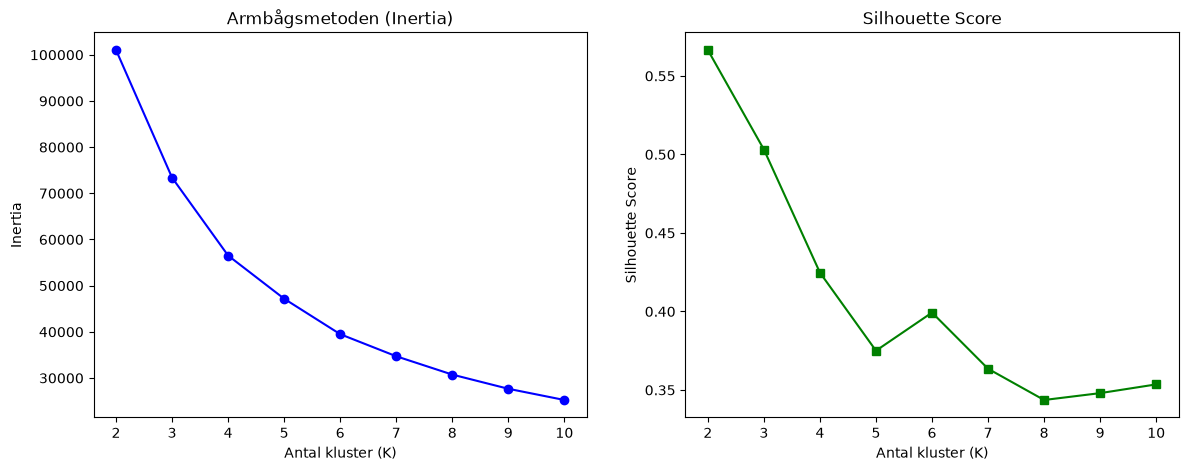

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("housing.csv")
X = df.loc[:, ["median_income", "latitude", "longitude"]]

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Rita grafer för att utvärdera optimalt K
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='b')
axes[0].set_title('Armbågsmetoden (Inertia)')
axes[0].set_xlabel('Antal kluster (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouette_scores, marker='s', color='g')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Antal kluster (K)')
axes[1].set_ylabel('Silhouette Score')

plt.show()

Baserat på graferna i bilden kan man utläsa följande för de tre valda variablerna (`median_income`, `latitude`, `longitude`):
- **Armbågsmetoden (Inertia, vänxter graf):** Kurvan faller brant upp till K = 4 och börjar därefter plana ut mer gradvid. En potentiell "armbåge" kan skönjas runt K = 4 eller K = 5, vilket indikerer att ytterligare kluster ger minskad avkastning i form av ökad kompakthet.

- **Silhouette Score (höger graf):** Ger det högsya värdet vid K = 2 (~0.57) och sjunker sedan krafigt för därefter ligga gasnka lågt, med en liten lokal topp vid K = 6 (~0,40).

**Slutstats:**
Det finns en klassisk målkonflikt här. Inertia pekar på att 4-5 kluster ger en bra kompromiss mellan kompakt struktur och antal grupper, medan Silhouette Score antyder att datan matematiskt sett har svårt att bilda knviskarpa, separta kluster vid högre K-värden (eftersom poängen sjunker stadigt från K = 2). I praktiken kan man därför behöva testa sig fram runt K = 4 till 6 för att se vilka grupper som ger mest affärsmässigt värde. 

### Uppgift 8.

Genomförandet av en klusteranalys på hr_employee_data.xlsx innebär att vi frångår det tidigare övervakade synsättet där målet var att förutsäga kolumnen left ($y$). Istället betraktar vi nu samtliga variabler som oberoende variabler ($x$) för att låta en oövervakad algoritm (t.ex. K-Means) upptäcka naturliga grupper (kluster) av medarbetare baserat på deras samlade profil (såsom lön, avdelning, arbetstimmar, projektantal, nöjdhetsgrad och om de slutat).

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ladda datasetet
excel_file = pd.ExcelFile("hr_employee_data.xlsx")
print(f"Tillgängliga blad: {excel_file.sheet_names}")
df = pd.read_excel(excel_file, sheet_name='HR_Employee_Data')

# 2. Förbered avidentifiering och feature-urval (betraktar alla variabler som X)
# Vi exkluderar Emp_Id eftersom det bara är ett unikt ID
X_data = df.drop(columns=['Emp_Id'])

numeric_features = X_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_data.select_dtypes(include=['object']).columns.tolist()

# 3. Skapa preprocessor för skalning och One-Hot-kodning
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X_data)

# 4. Utvärdera optimalt antal kluster (K) med Inertia och Silhouette Score
inertias = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_processed)
    inertias.append(km.inertia_)
    # Beräknar silhuettpoäng (använder stickprov för prestanda)
    sil_scores.append(silhouette_score(X_processed, labels, sample_size=3000, random_state=42))

print("\n--- Utvärdering av K ---")
for k, inertia, sil in zip(K_range, inertias, sil_scores):
    print(f"K={k} -> Inertia: {inertia:.2f}, Silhouette Score: {sil:.4f}")

# 5. Kör slutlig klustring med vald mängd kluster (t.ex. K=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_processed)

# Lägg till klustertillhörighet i en kopia av originaldatat
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

# 6. Analysera klusterprofiler (genomsnittsvärden för numeriska variabler per kluster)
cluster_summary = df_clustered.groupby('Cluster')[numeric_features].mean()

print("\n========================================")
print("       KLUSTERPROFILER (MEDELVÄRDEN)    ")
print("========================================")
print(cluster_summary)

print("\nStorlek på respektive kluster:")
print(df_clustered['Cluster'].value_counts())

Tillgängliga blad: ['HR_Employee_Data']


C:\Users\lindb\AppData\Local\Temp\ipykernel_25508\897892172.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_data.select_dtypes(include=['object']).columns.tolist()



--- Utvärdering av K ---
K=2 -> Inertia: 119308.65, Silhouette Score: 0.2126
K=3 -> Inertia: 103779.62, Silhouette Score: 0.2123
K=4 -> Inertia: 88993.72, Silhouette Score: 0.2290
K=5 -> Inertia: 76459.94, Silhouette Score: 0.2642
K=6 -> Inertia: 69590.38, Silhouette Score: 0.2755

       KLUSTERPROFILER (MEDELVÄRDEN)    
         satisfaction_level  last_evaluation  number_project  \
Cluster                                                        
0                  0.408912         0.515693        2.147844   
1                  0.444965         0.842477        5.092599   
2                  0.702897         0.718114        3.744193   
3                  0.656019         0.706019        3.752351   

         average_montly_hours  time_spend_company  Work_accident      left  \
Cluster                                                                      
0                  144.824949            3.101129       0.048255  0.820842   
1                  244.852315            5.206151       

För att ta analysen vidare kan vi titta närmare på hur de fyra klustren faktiskt skiljer sig åt när vi kombinerar de numeriska mätvärdena med avdelningar och lönestrukturer. Det ger en skarpare bild av vilka personalgrupper vi har att göra med.

#### Fördjupad profilering av klustren ($K=4$)
- **Kluster 0: "De understimulerade och avhoppsbenägna" (13.0% av personalen)**
  - Egenskaper: Mycket låg arbetsbelastning (snitt 2.1 projekt, ca 145 timmar/månad) och låg nöjdhet (0.41).
  - Utsatthet: **82% har lämnat företaget.**
  - Insikt: Detta tyder på att personal som har för lite att göra eller känner sig understimulerade snabbt tröttnar och söker sig vidare.
- **Kluster 1: "De överbelastade och utbrända" (19.7% av personalen)**
  - Egenskaper: Arbetar mest av alla (snitt ~245 timmar/månad, 5+ projekt) och har lång anställningstid (snitt 5.2 år). Trots det har de låg nöjdhet (0.44) och höga utvärderingar (0.84).
  - Utsatthet: **65% har lämnat företaget.**
  - Insikt: Det här är den klassiska "bränna ljuset i båda ändar"-profilen. Duktiga medarbetare som drar ett för stort lass och till slut lämnar på grund av överbelastning.
- **Kluster 2: "Kärntruppen – De stabila arbetarna" (65.2% av personalen)**
  - Egenskaper: Den stora basen med balanserade arbetstimmar (~199 timmar), bra nöjdhet (0.70) och normalt antal projekt.
  - Utsatthet: **Nästan 0% omsättning** (endast 0.16% har slutat).
  - Insikt: Ryggraden i organisationen som trivs och presterar stabilt utan att sticka ut åt extremt hållen.
- **Kluster 3: "De befordrade nyckelspelarna" (2.1% av personalen)**
  - Egenskaper: Utmärker sig genom att **100% har fått en befordran** under de senaste 5 åren. De har rimlig arbetsbelastning och god nöjdhet.
  - Utsatthet: Väldigt låg personalomsättning (~6% har slutat).
  - Insikt: Visar att karriärvägar och intern rekrytering/befordran är en extremt stark friskfaktor för att behålla talanger.

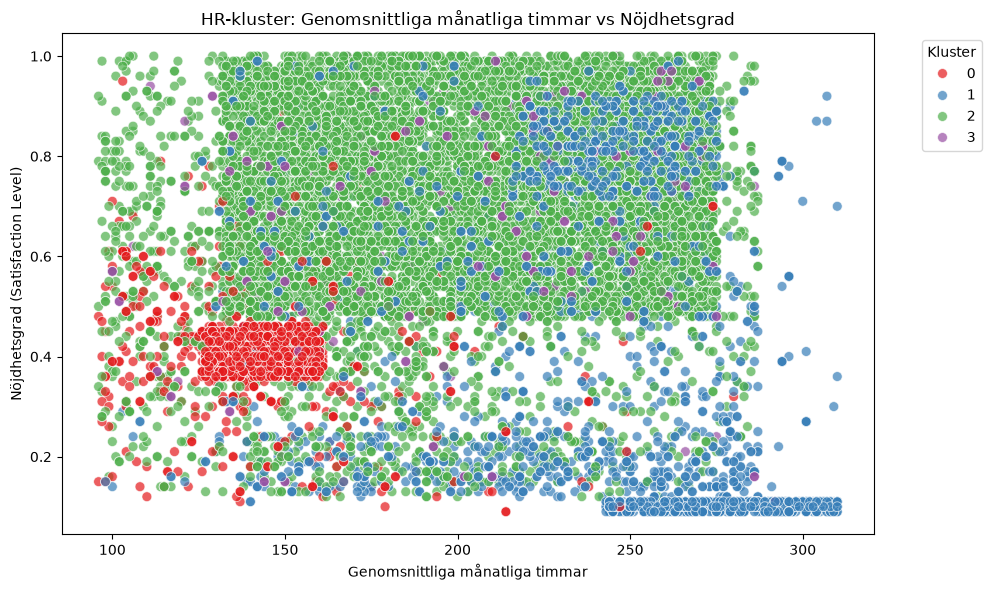

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clustered,  # <-- Ändrat från df till df_clustered
    x='average_montly_hours',
    y='satisfaction_level',
    hue='Cluster',
    palette='Set1',
    alpha=0.7,
    s=50
)

plt.title('HR-kluster: Genomsnittliga månatliga timmar vs Nöjdhetsgrad')
plt.xlabel('Genomsnittliga månatliga timmar')
plt.ylabel('Nöjdhetsgrad (Satisfaction Level)')
plt.legend(title='Kluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Klusteranalysen av HR-datan kan användas på flera konkreta sätt i verkligheten av en HR-avdelning eller företagsledning för att förbättra arbetsmiljön och minska personalomsättningen:

- **Proaktivt arbete mot personalavhopp (Retention):**
 Genom att identifiera riskprofiler (såsom den överbelastade gruppen med höga arbetstimmar och den understimulerade gruppen med låg beläggning) kan HR upptäcka vilka medarbetare som ligger i riskzonen för att sluta, och sätta in förebyggande stödinsatser innan det är för sent.

- **Resursfördelning och balansering av arbetsbelastning:** 
Om analysen visar att ett visst kluster av anställda konsekvent arbetar för mycket eller har en orimlig mängd projekt, kan chefer använda insikten för att omfördela arbetsuppgifter eller anställa förstärkning till drabbade team.

- **Skräddarsydda HR-strategier och förmåner:** 
Istället för att behandla hela personalstyrkan likadant kan organisationen skräddarsy sina initiativ. För vissa grupper kan fokus ligga på kompetensutveckling och karriärvägar (likt det befordrade klustret), medan andra kan behöva verktyg för bättre balans mellan arbete och fritid.

### Uppgift 9. 

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ladda datasetet från din lokala CSV-fil (ersätt med rätt filnamn om det behövs)
df = pd.read_csv("1980sClassics.csv")  # Byt till ditt faktiska filnamn

print("Datasetets dimensioner:", df.shape)
print(df.head())

Datasetets dimensioner: (998, 17)
                   Track              Artist Duration  Time_Signature  \
0                   Babe                Styx     3:38               4   
1               The Rose        Bette Midler     4:04               4   
2                   Cars          Gary Numan     4:08               4   
3                  Magic  Olivia Newton-John     2:17               4   
4  We Don’t Talk Anymore       Cliff Richard     3:37               4   

   Danceability  Energy  Key  Loudness  Mode  Speechiness  Acousticness  \
0         0.700   0.582   11    -5.960     0       0.0356       0.05020   
1         0.264   0.640    8    -6.221     1       0.0442       0.03930   
2         0.338   0.562    9    -7.181     1       0.0290       0.03900   
3         0.911   0.689    1    -6.176     1       0.2650       0.00119   
4         0.728   0.563    1    -8.053     0       0.1340       0.62100   

   Instrumentalness  Liveness  Valence    Tempo  Popularity  Year  
0       

In [7]:
# Skriv ut alla kolumnnamn för att se vad de heter i din fil
print("Tillgängliga kolumner i din fil:")
print(df.columns.tolist())

Tillgängliga kolumner i din fil:
['Track', 'Artist', 'Duration', 'Time_Signature', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Popularity', 'Year']


In [8]:
# 2. Välj ut relevanta numeriska Spotify-features för klustringen
feature_cols = ['Danceability', 'Energy', 'Valence', 'Tempo', 'Loudness', 'Acousticness']
X = df[feature_cols].dropna()


In [9]:
# 3. Skala datan (standardisering är ett krav för K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

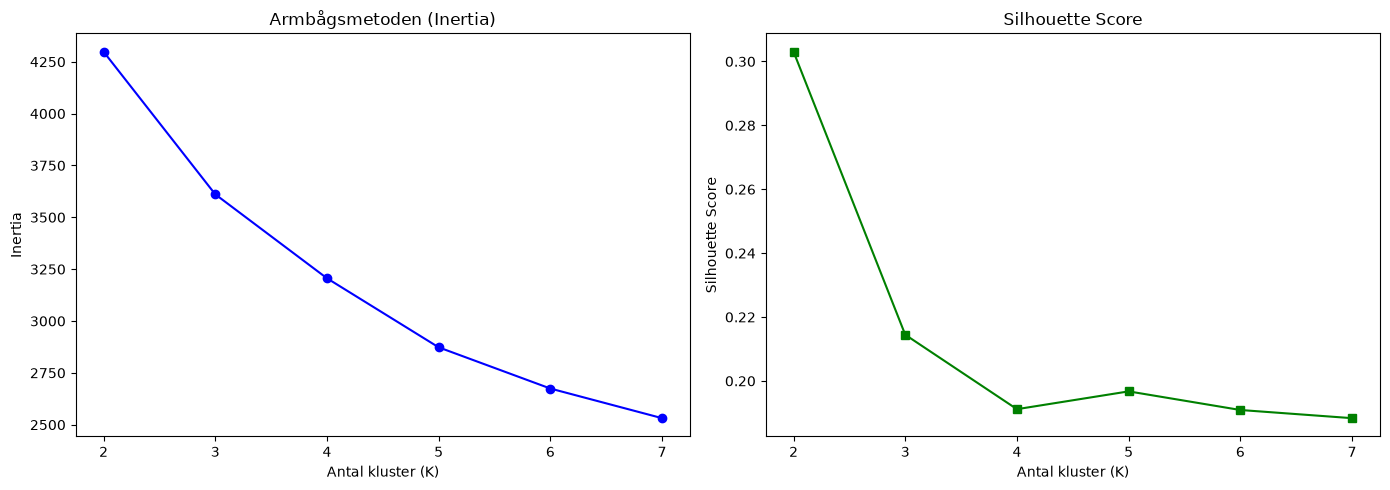

In [10]:
# 4. Utvärdera optimalt antal kluster (K) med Inertia och Silhouette Score
inertias = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Rita utvärderingsgrafer
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, marker='o', color='b')
axes[0].set_title('Armbågsmetoden (Inertia)')
axes[0].set_xlabel('Antal kluster (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='s', color='g')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Antal kluster (K)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

In [11]:
# 5. Kör slutlig klustring med valt antal kluster (t.ex. K = 4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clustered = df.loc[X.index].copy()
df_clustered['Cluster'] = kmeans.fit_predict(X_scaled)

In [12]:
# 6. Analysera klusterprofiler (medelvärden per kluster)
cluster_summary = df_clustered.groupby('Cluster')[feature_cols].mean()
print("\n========================================")
print("       KLUSTERPROFILER (80-TALET)       ")
print("========================================")
print(cluster_summary)


       KLUSTERPROFILER (80-TALET)       
         Danceability    Energy   Valence       Tempo   Loudness  Acousticness
Cluster                                                                       
0            0.486372  0.704000  0.466364  150.152447  -7.172149      0.169097
1            0.736738  0.565336  0.757399  114.225893 -11.240118      0.183769
2            0.675417  0.796120  0.717128  114.590897  -6.137197      0.137822
3            0.517069  0.359235  0.306702  113.077646 -12.306328      0.604802


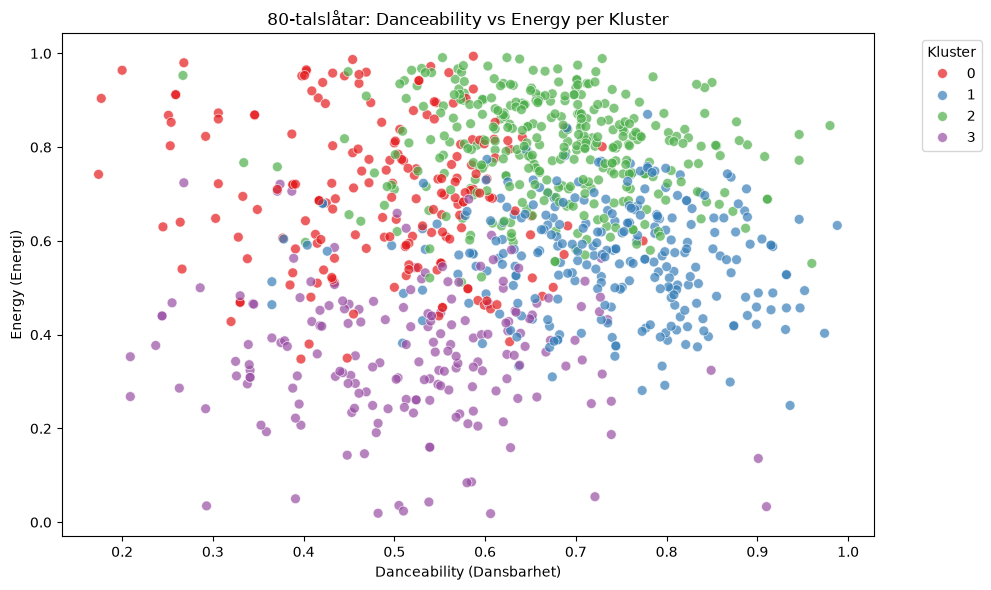

In [14]:
# 7. Visualisera med spridningsdiagram (Danceability vs Energy)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clustered,
    x='Danceability',
    y='Energy',
    hue='Cluster',
    palette='Set1',
    alpha=0.7,
    s=50
)
plt.title('80-talslåtar: Danceability vs Energy per Kluster')
plt.xlabel('Danceability (Dansbarhet)')
plt.ylabel('Energy (Energi)')
plt.legend(title='Kluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Mina grafer visar följande: 
- **Armbågsmetoden (Inertia):** Visar en ganska jämn kurva där minskningen av tröghet planar ut gradvis. Ett rimligt val för antal kluster ($K$) brukar här ligga runt 4 eller 5

- **Silhouette Score:** Högst värde fås vid $K=2$ (ca 0.30), men eftersom du valde $K=4$ i din visualisering får du en fin uppdelning i fyra distinkta musikprofiler.

- **Spridningsdiagrammet (Danceability vs Energy):** Visar att mina fyra kluster har delat in 80-talslåtarna i tydliga musikaliska fack (t.ex. hög energi/hög dansbarhet vs låg energi/låg dansbarhet).

#### Nästa steg: Skriv ut och analysera klusterprofilerna. 
För att förstå vad som döljer sig i varje kluster kan man köra koden nedan för att se medelvärdena för de olika egenskaperna per kluster, samt få exempel på några låtar i varje grupp:


In [15]:
# Koppla klustren till din dataframe (förutsatt att df_clustered skapats med K=4)
# Om du kör med K=4:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clustered = df.copy()
df_clustered['Cluster'] = kmeans.fit_predict(X_scaled)

# 1. Skriv ut medelvärden för varje kluster
cluster_summary = df_clustered.groupby('Cluster')[feature_cols].mean()
print("--- KLUSTERPROFILER (MEDELVÄRDEN) ---")
print(cluster_summary)

# 2. Se exempel på låtar (Track och Artist) i varje kluster
print("\n--- EXEMPEL PÅ LÅTAR PER KLUSTER ---")
for cluster_id in range(optimal_k):
    sample_tracks = df_clustered[df_clustered['Cluster'] == cluster_id][['Track', 'Artist']].head(3)
    print(f"\nKluster {cluster_id}:")
    print(sample_tracks.to_string(index=False))

--- KLUSTERPROFILER (MEDELVÄRDEN) ---
         Danceability    Energy   Valence       Tempo   Loudness  Acousticness
Cluster                                                                       
0            0.486372  0.704000  0.466364  150.152447  -7.172149      0.169097
1            0.736738  0.565336  0.757399  114.225893 -11.240118      0.183769
2            0.675417  0.796120  0.717128  114.590897  -6.137197      0.137822
3            0.517069  0.359235  0.306702  113.077646 -12.306328      0.604802

--- EXEMPEL PÅ LÅTAR PER KLUSTER ---

Kluster 0:
   Track       Artist
The Rose Bette Midler
    Cars   Gary Numan
  Desire    Andy Gibb

Kluster 1:
                        Track          Artist
                Rock With You Michael Jackson
                  Upside Down      Diana Ross
Escape (THE Piña Colada Song)   Rupert Holmes

Kluster 2:
Track             Artist
 Babe               Styx
Magic Olivia Newton-John
  Him      Rupert Holmes

Kluster 3:
                Track        A

Mina klusterprofiler visar en mycket tydlig och logisk uppdelning av 80-talslåtarna baserat på deras ljudegenskaper. Här är en genomgång av vad varje kluster representerar:

- **Kluster 0: "High-Tempo & Drastic Beats"**

  - Egenskaper: Utmärker sig främst genom ett **mycket högt tempo (snitt 150.1 BPM)** och hög energi (0.70).

  - Profil: Snabba, drivande låtar som skiljer sig från standardrytmen.

- **Kluster 1: "Groovy Dance & Upbeat Pop"**

  - Egenskaper: Hög **danceability (0.74)** och högt glädjeindex **(valence 0.76)**, med artister som Michael Jackson och Diana Ross.

  - Profil: 80-talets klassiska dans- och funk-influerade pophits som sätter igång fötterna.

- **Kluster 2: "Energetic Rock & Arena Anthems"**

  - Egenskaper: Den mest energiska gruppen (**energy 0.80**), hög dansbarhet (0.68) och högst volym/tryck (**loudness -6.1 dB**), med låtar som Styx ("Babe").

  - Profil: Stora, mäktiga rocklåtar och arenahits med mycket driv och kraft.

- **Kluster 3: "Acoustic Ballads & Slow Tracks"**

  - Egenskaper: Dramatiskt högre **acousticness (0.60)**, låg energi (0.36), låg valence (0.30) och dämpad volym (-12.3 dB), med artister som Kenny Rogers och Air Supply.

  - Profil: Lugna ballader, akustiska spår och känslosamma långsamma låtar.

#### Hur detta kan användas i verkligheten
Den här typen av klustring av 80-talsmusik kan tillämpas på flera sätt i den verkliga musikbranschen:

- **Automatiserad spellistegenerering:** Streamingplattformar (som Spotify) kan använda ljudbaserade kluster för att skapa smarta temaspellistor, till exempel "80s Workout Bangers" (hög energi och dansbarhet) kontra "80s Late Night Ballads" (låg energi, akustiskt).

- **Rekommendationsalgoritmer:** Om en lyssnare gillar en viss låt från ett visst kluster, kan systemet rekommendera andra låtar med liknande dynamiska egenskaper snarare än att bara titta på genre.

- **Musik- och trendanalys:** Skivbolag eller producenter kan analysera vilka ljudprofiler som dominerade hitlistorna under 1980-talet för att förstå vad som skapar en framgångsrik låtstruktur.